# Model Comparison: Readiness Score vs. Its Ingredients

This notebook isolates exactly what Garmin's Training Readiness score contributes, by fitting three nested models and comparing them directly.

| Model | Predictors | Question it answers |
|---|---|---|
| **A** | `readiness_score` only | Does readiness alone predict performance? |
| **B** | `readiness_score` + weather + time of day | Does adding exogenous context help readiness? |
| **C** | Raw readiness components + weather + time of day *(no readiness score)* | Do readiness's raw inputs beat the composite? |

### Raw readiness components (Model C)
Garmin builds the composite score from six factor percentages. Model C replaces the composite with the underlying raw signals:

| Raw signal | Readiness factor it feeds |
|---|---|
| `hrv_weekly_avg_ms` | HRV factor |
| `sleep_score` | Sleep score factor |
| `recovery_time_h` | Recovery time factor |
| `acwr` | ACWR factor |
| `stress_avg` | Stress history factor |

> **Note:** The sleep *history* factor (multi-day rolling sleep trend) doesn't have a direct raw equivalent in our export. The five signals above cover the remaining five readiness components.

### Context predictors (Models B & C)
- `weather_category` — clear / overcast / rainy (derived from precipitation + cloud cover)
- `temperature_c` — ambient temperature (°C)
- `humidity` — relative humidity (0–1)
- `wind_speed_ms` — wind speed (m/s)
- `hour_of_day` — hour activity started (0–23)

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, KFold
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

DB_PATH = '../data/healthdata.duckdb'
con = duckdb.connect(DB_PATH, read_only=True)
print('Connected to', DB_PATH)

Connected to ../data/healthdata.duckdb


---
## 1. Load data

In [2]:
RIDE_QUERY = """
    SELECT
        activity_date,
        started_at,
        average_watts,
        -- composite readiness
        readiness_score,
        -- raw readiness components
        readiness_hrv_weekly_avg_ms   AS hrv_weekly_avg_ms,
        sleep_score,
        recovery_time_h,
        acwr,
        stress_avg,
        -- context (weather + time)
        weather_temperature_c         AS temperature_c,
        humidity_fraction             AS humidity,
        wind_speed_ms,
        precipitation_intensity,
        cloud_cover_fraction
    FROM main_marts.fct_ride
    WHERE readiness_score    IS NOT NULL
      AND average_watts      IS NOT NULL
      AND average_watts      > 0
      AND distance_km        > 5
      AND coalesce(commute, false) = false
    ORDER BY activity_date
"""

RUN_QUERY = """
    SELECT
        activity_date,
        started_at,
        gap_min_per_km,
        -- composite readiness
        readiness_score,
        -- raw readiness components
        readiness_hrv_weekly_avg_ms   AS hrv_weekly_avg_ms,
        sleep_score,
        recovery_time_h,
        acwr,
        stress_avg,
        -- context (weather + time)
        weather_temperature_c         AS temperature_c,
        humidity_fraction             AS humidity,
        wind_speed_ms,
        precipitation_intensity,
        cloud_cover_fraction
    FROM main_marts.fct_run
    WHERE readiness_score    IS NOT NULL
      AND gap_min_per_km     IS NOT NULL
      AND gap_min_per_km     > 3
      AND gap_min_per_km     < 12
      AND distance_km        > 1
    ORDER BY activity_date
"""

rides_raw = con.execute(RIDE_QUERY).df()
runs_raw  = con.execute(RUN_QUERY).df()
print(f'Rides: {len(rides_raw)}   Runs: {len(runs_raw)}')
print(f"Rides range: {rides_raw['activity_date'].min()} to {rides_raw['activity_date'].max()}")
print(f"Runs range:  {runs_raw['activity_date'].min()} to {runs_raw['activity_date'].max()}")

Rides: 183   Runs: 74
Rides range: 2023-12-30 00:00:00 to 2026-04-04 00:00:00
Runs range:  2023-12-30 00:00:00 to 2026-03-28 00:00:00


In [3]:
def engineer_features(df):
    df = df.copy()
    df['hour_of_day'] = pd.to_datetime(df['started_at']).dt.hour
    df['weather_category'] = np.select(
        [df['precipitation_intensity'] > 0.05, df['cloud_cover_fraction'] > 0.65],
        ['rainy', 'overcast'],
        default='clear'
    )
    return df

rides = engineer_features(rides_raw)
runs  = engineer_features(runs_raw)
runs['gap_speed'] = -runs['gap_min_per_km']   # higher = faster

# ── check null rates for Model C predictors ──────────────────────────────────
MODEL_C_RAW = ['hrv_weekly_avg_ms', 'sleep_score', 'recovery_time_h', 'acwr', 'stress_avg']
CONTEXT     = ['temperature_c', 'humidity', 'wind_speed_ms', 'hour_of_day']

print('Null rates for raw readiness components (rides / runs):')
for col in MODEL_C_RAW:
    rn_ride = rides[col].isna().sum()
    rn_run  = runs[col].isna().sum()
    print(f'  {col:<25}  rides null={rn_ride}  runs null={rn_run}')

Null rates for raw readiness components (rides / runs):
  hrv_weekly_avg_ms          rides null=0  runs null=0
  sleep_score                rides null=0  runs null=0
  recovery_time_h            rides null=0  runs null=0
  acwr                       rides null=1  runs null=0
  stress_avg                 rides null=0  runs null=0


> **Time zone note:** `started_at` is stored as *local time* by Strava (verified in `stg_strava__activities.sql`). Extracting `.dt.hour` therefore gives the local clock hour at the activity's location, which is exactly what we want for a circadian/behavioral predictor. Activities recorded in different time zones are correctly compared on their local hour, not a UTC offset.

---
## 2. Model definitions

All models use OLS (statsmodels) for interpretable coefficients and Ridge with 5-fold CV for honest out-of-sample R². Weather category is dummy-coded with *clear* as the reference level.

In [4]:
# ── Feature sets ─────────────────────────────────────────────────────────────
MODEL_A_FEATS = ['readiness_score']

MODEL_B_FEATS = ['readiness_score'] + CONTEXT  # readiness + exogenous context only

MODEL_C_FEATS = MODEL_C_RAW + CONTEXT          # raw components + context, no readiness

MODELS = {
    'A — readiness only':            MODEL_A_FEATS,
    'B — readiness + context':       MODEL_B_FEATS,
    'C — raw components + context':  MODEL_C_FEATS,
}

print('Model A features:', MODEL_A_FEATS)
print('Model B features:', MODEL_B_FEATS)
print('Model C features:', MODEL_C_FEATS)

Model A features: ['readiness_score']
Model B features: ['readiness_score', 'temperature_c', 'humidity', 'wind_speed_ms', 'hour_of_day']
Model C features: ['hrv_weekly_avg_ms', 'sleep_score', 'recovery_time_h', 'acwr', 'stress_avg', 'temperature_c', 'humidity', 'wind_speed_ms', 'hour_of_day']


In [5]:
def fit_model(df, target_col, continuous_feats, label):
    """
    Fit OLS + Ridge CV for one model spec.
    Weather category is added as dummies if temperature_c is in the feature set
    (i.e., Models B and C but not A).
    Returns dict with ols model, CV R² mean/std, n.
    """
    use_weather = 'temperature_c' in continuous_feats
    needed = continuous_feats + (['weather_category'] if use_weather else []) + [target_col]
    data = df[needed].dropna().copy()

    if use_weather:
        data['w_overcast'] = (data['weather_category'] == 'overcast').astype(int)
        data['w_rainy']    = (data['weather_category'] == 'rainy').astype(int)
        ols_feats = continuous_feats + ['w_overcast', 'w_rainy']
    else:
        ols_feats = continuous_feats

    # OLS
    ols = smf.ols(target_col + ' ~ ' + ' + '.join(ols_feats), data=data).fit(cov_type='hc3')

    # Ridge CV
    if use_weather:
        weather_d = pd.get_dummies(data['weather_category'], prefix='w', drop_first=True)
        X = pd.concat([data[continuous_feats], weather_d], axis=1).values.astype(float)
    else:
        X = data[continuous_feats].values.astype(float)
    y = data[target_col].values

    alphas = np.logspace(-2, 4, 50)
    pipe   = make_pipeline(StandardScaler(), RidgeCV(alphas=alphas, cv=5))
    cv     = KFold(n_splits=5, shuffle=True, random_state=42)
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2')
    pipe.fit(X, y)

    return {
        'label':    label,
        'n':        len(data),
        'ols':      ols,
        'ols_r2':   ols.rsquared,
        'ols_r2adj':ols.rsquared_adj,
        'ols_fp':   ols.f_pvalue,
        'cv_r2':    scores.mean(),
        'cv_r2_std':scores.std(),
        'pipe':     pipe,
        'best_alpha': pipe.named_steps['ridgecv'].alpha_,
        'X':        X,
        'y':        y,
    }

---
## 3. Fit all models — rides

In [6]:
ride_results = {}
for name, feats in MODELS.items():
    res = fit_model(rides, 'average_watts', feats, name)
    ride_results[name] = res
    print(f'Model {name}')
    print(f'  n={res["n"]}  OLS R²={res["ols_r2"]:.3f}  adj-R²={res["ols_r2adj"]:.3f}  F-p={res["ols_fp"]:.4f}  CV R²={res["cv_r2"]:.3f} ±{res["cv_r2_std"]:.3f} Best λ={res["pipe"].named_steps["ridgecv"].alpha_:.4f}')
    coef = res['ols'].summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|']].round(4)
    print(coef.to_string())
    print()

Model A — readiness only
  n=183  OLS R²=0.023  adj-R²=0.017  F-p=0.0705  CV R²=-0.089 ±0.066 Best λ=1048.1131
                    Coef.  Std.Err.        z   P>|z|
Intercept        124.3823   10.1214  12.2890  0.0000
readiness_score    0.2690    0.1479   1.8191  0.0689

Model B — readiness + context
  n=183  OLS R²=0.250  adj-R²=0.220  F-p=0.0000  CV R²=0.115 ±0.110 Best λ=35.5648
                   Coef.  Std.Err.       z   P>|z|
Intercept        35.1077   13.4559  2.6091  0.0091
readiness_score   0.2763    0.1576  1.7533  0.0796
temperature_c     0.3781    0.3488  1.0839  0.2784
humidity         22.8425   17.0489  1.3398  0.1803
wind_speed_ms     4.0574    1.5543  2.6105  0.0090
hour_of_day       3.1413    0.6036  5.2047  0.0000
w_overcast        7.8075    6.2004  1.2592  0.2080
w_rainy         -11.3965    9.6215 -1.1845  0.2362

Model C — raw components + context
  n=182  OLS R²=0.271  adj-R²=0.223  F-p=0.0000  CV R²=0.157 ±0.075 Best λ=82.8643
                      Coef.  Std.Err. 

---
## 4. Fit all models — runs

In [7]:
run_results = {}
for name, feats in MODELS.items():
    res = fit_model(runs, 'gap_speed', feats, name)
    run_results[name] = res
    print(f'Model {name}')
    print(f'  n={res["n"]}  OLS R²={res["ols_r2"]:.3f}  adj-R²={res["ols_r2adj"]:.3f}  F-p={res["ols_fp"]:.4f}  CV R²={res["cv_r2"]:.3f} ±{res["cv_r2_std"]:.3f} Best λ={res["pipe"].named_steps["ridgecv"].alpha_:.4f}')
    coef = res['ols'].summary2().tables[1][['Coef.', 'Std.Err.', 'z', 'P>|z|']].round(4)
    print(coef.to_string())
    print()

Model A — readiness only
  n=74  OLS R²=0.021  adj-R²=0.007  F-p=0.1811  CV R²=-0.551 ±0.727 Best λ=10000.0000
                  Coef.  Std.Err.        z   P>|z|
Intercept       -5.5306    0.5310 -10.4160  0.0000
readiness_score -0.0114    0.0084  -1.3503  0.1769

Model B — readiness + context
  n=66  OLS R²=0.276  adj-R²=0.189  F-p=0.5258  CV R²=-0.155 ±0.186 Best λ=1048.1131
                  Coef.  Std.Err.       z   P>|z|
Intercept       -4.3260    1.9111 -2.2636  0.0236
readiness_score -0.0033    0.0069 -0.4740  0.6355
temperature_c   -0.0071    0.0104 -0.6888  0.4910
humidity         0.5608    1.0025  0.5594  0.5759
wind_speed_ms    0.0495    0.0659  0.7516  0.4523
hour_of_day     -0.1005    0.0689 -1.4578  0.1449
w_overcast       0.0314    0.1777  0.1766  0.8599
w_rainy         -1.1870    0.7195 -1.6498  0.0990

Model C — raw components + context
  n=66  OLS R²=0.381  adj-R²=0.254  F-p=0.6817  CV R²=-0.163 ±0.194 Best λ=3237.4575
                    Coef.  Std.Err.       z   P>|

---
## 5. Model comparison

                       Model  Ride n  Ride OLS R²  Ride CV R²  Run n  Run OLS R²  Run CV R²
          A — readiness only     183        0.023      -0.089     74       0.021     -0.551
     B — readiness + context     183        0.250       0.115     66       0.276     -0.155
C — raw components + context     182        0.271       0.157     66       0.381     -0.163


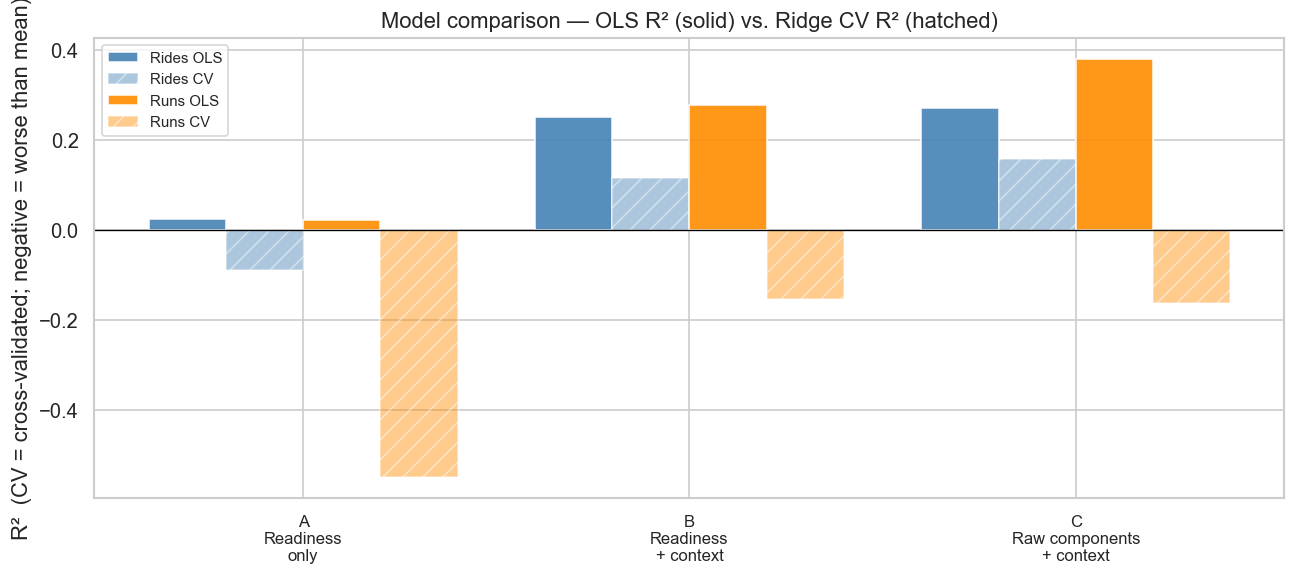

In [8]:
# ── Summary table ─────────────────────────────────────────────────────────────
rows = []
for name in MODELS:
    rr = ride_results[name]
    rn = run_results[name]
    rows.append({
        'Model':          name,
        'Ride n':         rr['n'],
        'Ride OLS R²':    round(rr['ols_r2'],    3),
        'Ride CV R²':     round(rr['cv_r2'],     3),
        'Run n':          rn['n'],
        'Run OLS R²':     round(rn['ols_r2'],    3),
        'Run CV R²':      round(rn['cv_r2'],     3),
    })

tbl = pd.DataFrame(rows)
print(tbl.to_string(index=False))

# ── Bar chart: OLS vs CV R² for each model ───────────────────────────────────
model_labels = ['A\nReadiness\nonly', 'B\nReadiness\n+ context', 'C\nRaw components\n+ context']
x = np.arange(len(MODELS))
w = 0.2

ride_ols = [ride_results[m]['ols_r2'] for m in MODELS]
ride_cv  = [ride_results[m]['cv_r2']  for m in MODELS]
run_ols  = [run_results[m]['ols_r2']  for m in MODELS]
run_cv   = [run_results[m]['cv_r2']   for m in MODELS]

fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - 1.5*w, ride_ols, w, label='Rides OLS',    color='steelblue',   alpha=0.9)
ax.bar(x - 0.5*w, ride_cv,  w, label='Rides CV',     color='steelblue',   alpha=0.45, hatch='//')
ax.bar(x + 0.5*w, run_ols,  w, label='Runs OLS',     color='darkorange',  alpha=0.9)
ax.bar(x + 1.5*w, run_cv,   w, label='Runs CV',      color='darkorange',  alpha=0.45, hatch='//')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel('R²  (CV = cross-validated; negative = worse than mean)')
ax.set_title('Model comparison — OLS R² (solid) vs. Ridge CV R² (hatched)')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.show()

---
## 5b. Multicollinearity check — VIF scores (Models B & C)

VIF > 10 is the conventional threshold for problematic multicollinearity; VIF > 5 warrants attention. Model A has a single predictor so VIF is trivially 1 and is skipped.

In [9]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def compute_vif(res):
    """Return a DataFrame of VIF scores for all non-intercept predictors."""
    target = res['ols'].model.endog_names
    X = res['ols'].model.data.frame.drop(columns=[target])
    # Keep only numeric columns (drops raw weather_category string)
    X = X.select_dtypes(include=[np.number])
    X = X.assign(Intercept=1.0)
    cols = [c for c in X.columns if c != 'Intercept']
    X_arr = X[cols + ['Intercept']].values.astype(float)
    vif_vals = [variance_inflation_factor(X_arr, i) for i in range(len(cols))]
    return pd.DataFrame({'Feature': cols, 'VIF': vif_vals}).set_index('Feature').round(2)

for sport_label, results in [('Rides', ride_results), ('Runs', run_results)]:
    print(f'─── {sport_label} ───────────────────────────────────────────────')
    for model_name in ['B — readiness + context', 'C — raw components + context']:
        vif_df = compute_vif(results[model_name])
        vif_df['flag'] = vif_df['VIF'].apply(lambda v: '⚠ >10' if v > 10 else ('△ >5' if v > 5 else ''))
        print(f'\n  Model {model_name}')
        print(vif_df.to_string())
    print()

─── Rides ───────────────────────────────────────────────

  Model B — readiness + context
                  VIF flag
Feature                   
readiness_score  1.18     
temperature_c    1.08     
humidity         1.44     
wind_speed_ms    1.18     
hour_of_day      1.34     
w_overcast       1.24     
w_rainy          1.27     

  Model C — raw components + context
                    VIF flag
Feature                     
hrv_weekly_avg_ms  1.35     
sleep_score        1.55     
recovery_time_h    1.33     
acwr               1.27     
stress_avg         1.39     
temperature_c      1.27     
humidity           1.52     
wind_speed_ms      1.19     
hour_of_day        1.63     
w_overcast         1.24     
w_rainy            1.30     

─── Runs ───────────────────────────────────────────────

  Model B — readiness + context
                  VIF flag
Feature                   
readiness_score  1.12     
temperature_c    1.26     
humidity         1.86     
wind_speed_ms    1.11    

---
## 6. Coefficient plots — all three models side by side

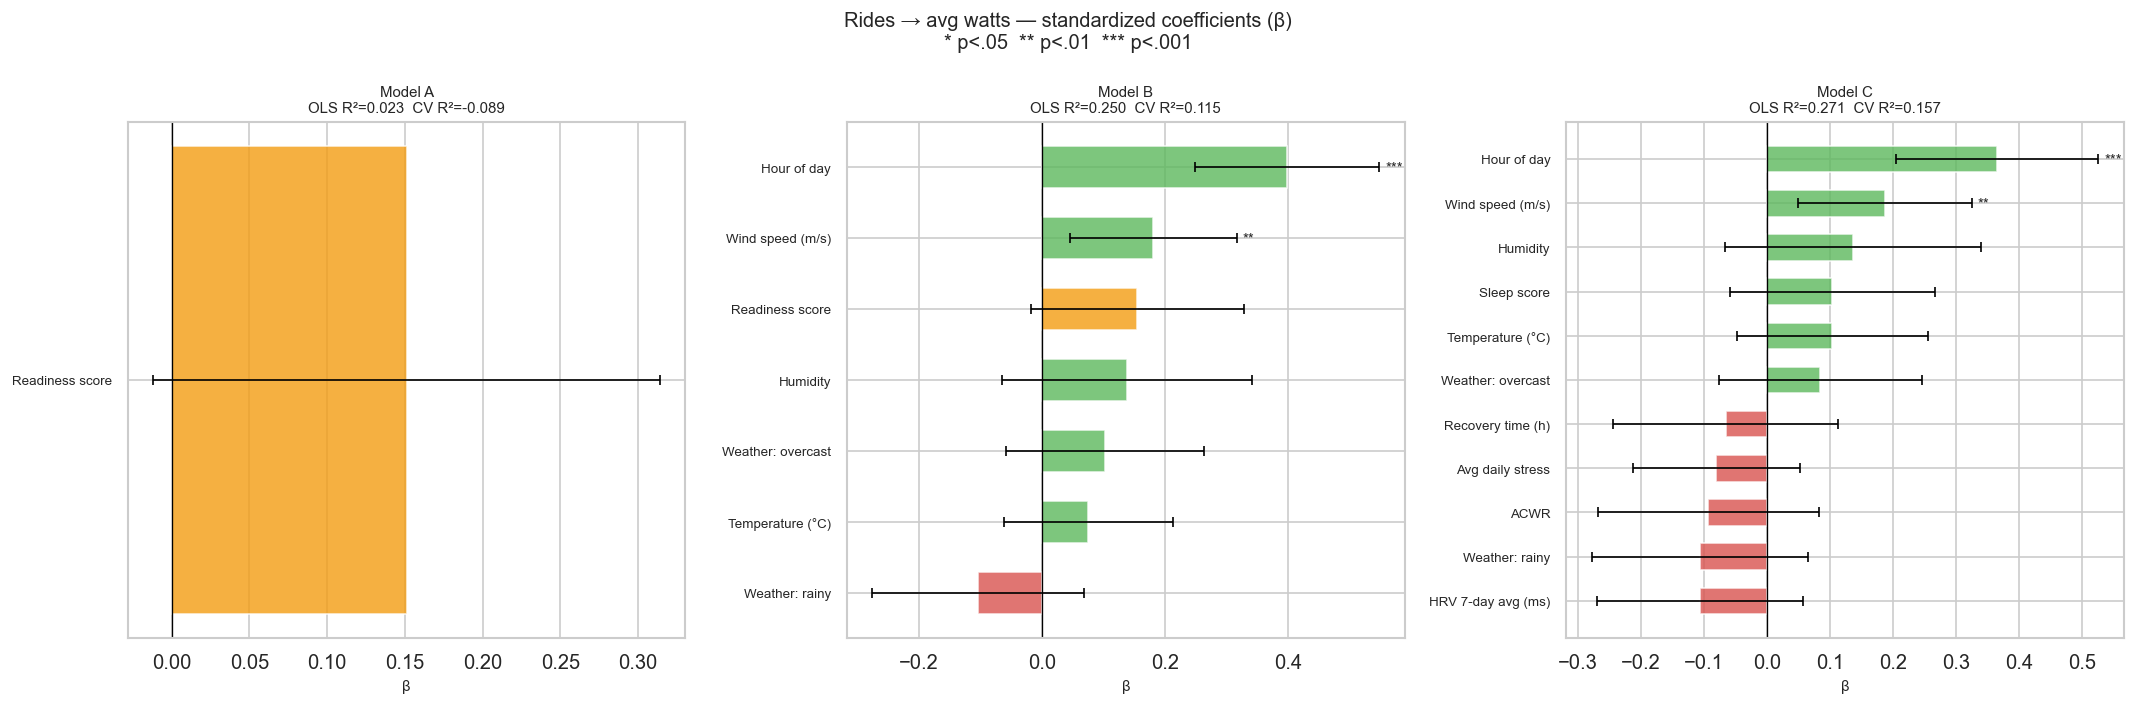

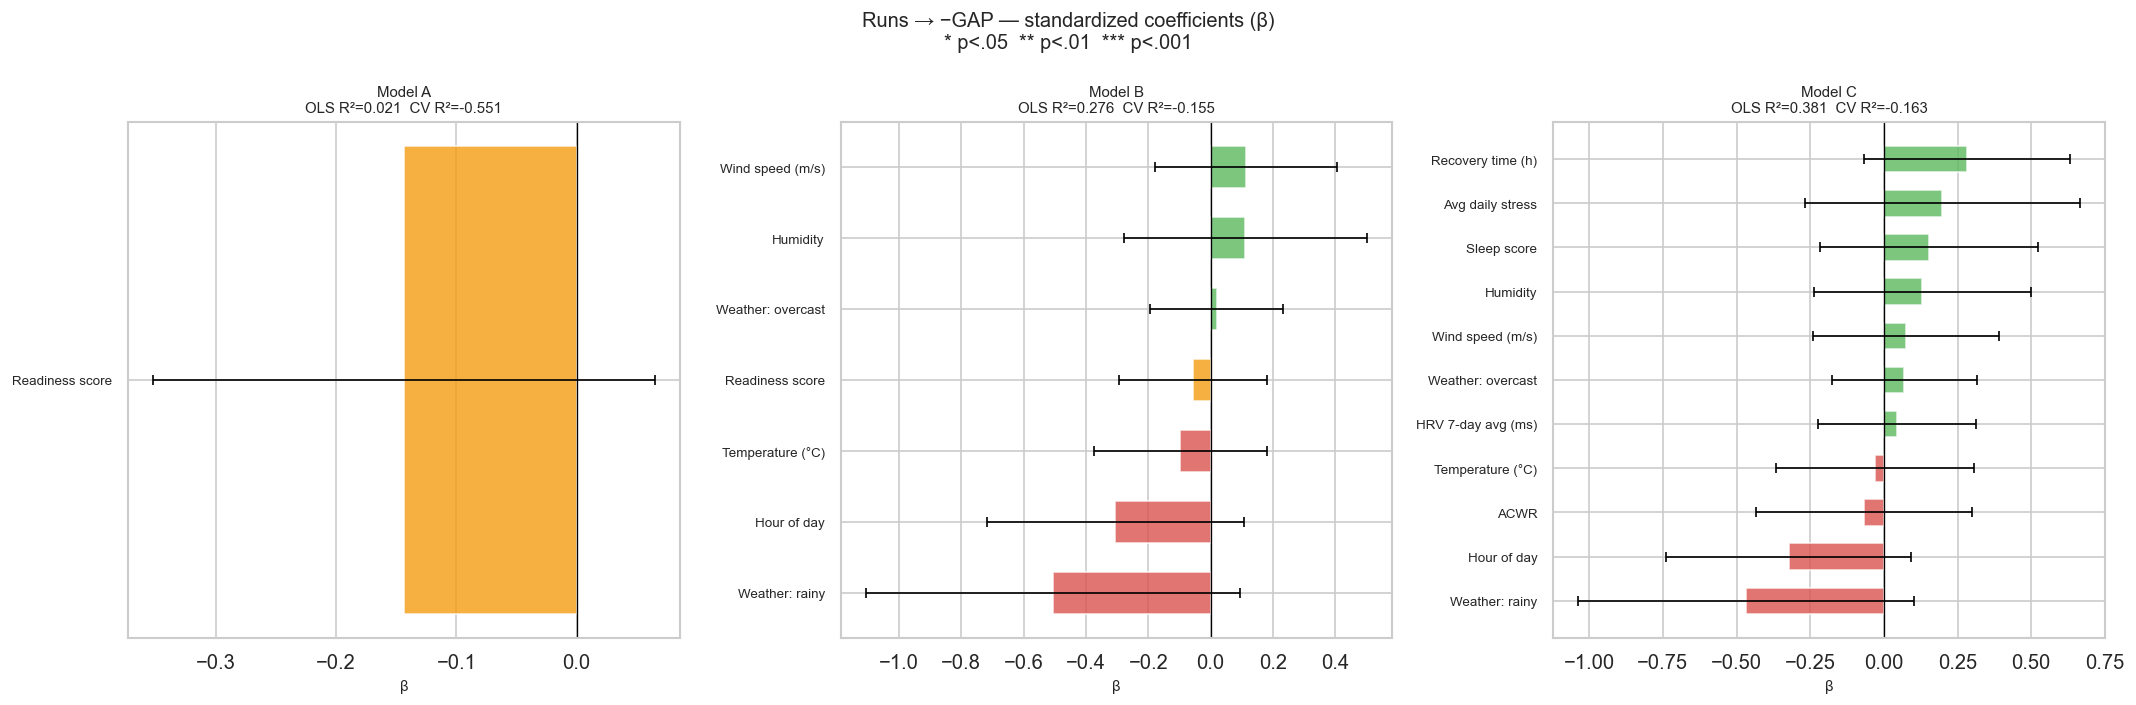

In [10]:
LABEL_MAP = {
    'readiness_score':   'Readiness score',
    'hrv_weekly_avg_ms': 'HRV 7-day avg (ms)',
    'sleep_score':       'Sleep score',
    'recovery_time_h':   'Recovery time (h)',
    'acwr':              'ACWR',
    'stress_avg':        'Avg daily stress',
    'temperature_c':     'Temperature (°C)',
    'humidity':          'Humidity',
    'wind_speed_ms':     'Wind speed (m/s)',
    'hour_of_day':       'Hour of day',
    'w_overcast':        'Weather: overcast',
    'w_rainy':           'Weather: rainy',
}

def standardized_coef_plot(results_dict, sport_label):
    """Side-by-side standardized coefficient plots for all three models."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    fig.suptitle(f'{sport_label} — standardized coefficients (β)\n* p<.05  ** p<.01  *** p<.001', fontsize=12)

    for ax, (model_name, res) in zip(axes, results_dict.items()):
        df_used    = rides if 'watts' in str(res['ols'].model.endog_names) else runs
        target_col = res['ols'].model.endog_names
        feats_used = [f for f in res['ols'].params.index if f != 'Intercept']

        # Re-fit on z-scored data to get standardized betas
        needed = [c.replace('w_overcast','weather_category').replace('w_rainy','weather_category')
                  for c in feats_used]
        # Simpler: just standardize the continuous terms directly from the original data
        ols_m = res['ols']
        params = ols_m.params.drop('Intercept')
        ci     = ols_m.conf_int().drop('Intercept')
        pvals  = ols_m.pvalues.drop('Intercept')

        # Standardize by multiplying each coef by sd(X)/sd(y)
        data_sub = res['ols'].model.data.frame
        sd_y = data_sub[target_col].std()
        std_params = {}
        std_ci_lo  = {}
        std_ci_hi  = {}
        for feat in params.index:
            if feat in data_sub.columns:
                sd_x = data_sub[feat].std()
            else:
                sd_x = 0.5  # binary dummy
            scale = sd_x / sd_y if sd_y > 0 else 1
            std_params[feat] = params[feat] * scale
            std_ci_lo[feat]  = ci.loc[feat, 0] * scale
            std_ci_hi[feat]  = ci.loc[feat, 1] * scale

        coefs  = pd.Series(std_params).rename(LABEL_MAP).sort_values()
        ci_lo  = pd.Series(std_ci_lo).rename(LABEL_MAP).reindex(coefs.index)
        ci_hi  = pd.Series(std_ci_hi).rename(LABEL_MAP).reindex(coefs.index)
        pvs    = pvals.rename(LABEL_MAP).reindex(coefs.index)

        colors = ['#f39c12' if 'Readiness' in idx else
                  '#5cb85c' if v >= 0 else '#d9534f'
                  for idx, v in zip(coefs.index, coefs.values)]

        y_pos = np.arange(len(coefs))
        ax.barh(y_pos, coefs.values, color=colors, alpha=0.8, edgecolor='white', height=0.6)
        ax.errorbar(coefs.values, y_pos,
                    xerr=[coefs.values - ci_lo.values, ci_hi.values - coefs.values],
                    fmt='none', color='black', linewidth=1, capsize=3)
        ax.set_yticks(y_pos)
        ax.set_yticklabels(coefs.index, fontsize=8)
        ax.axvline(0, color='black', linewidth=0.8)

        for i, (feat, p) in enumerate(pvs.items()):
            star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
            if star:
                xpos = ci_hi.iloc[i] + 0.01
                ax.text(xpos, i, star, va='center', fontsize=9)

        short_name = model_name.split('—')[0].strip()
        r2     = res['ols_r2']
        cv_r2  = res['cv_r2']
        ax.set_title(f'Model {short_name}\nOLS R²={r2:.3f}  CV R²={cv_r2:.3f}', fontsize=9)
        ax.set_xlabel('β', fontsize=9)

    plt.tight_layout()
    plt.show()

standardized_coef_plot(ride_results, 'Rides → avg watts')
standardized_coef_plot(run_results,  'Runs → −GAP')

---
## 7. Summary & findings

In [11]:
# ── Print a clean findings table ──────────────────────────────────────────────
print('RIDES — model comparison')
print(f'{"Model":<35} {"OLS R²":>8} {"adj-R²":>8} {"CV R²":>8} {"F-p":>8}')
print('-' * 75)
for name, res in ride_results.items():
    print(f'{name:<35} {res["ols_r2"]:>8.3f} {res["ols_r2adj"]:>8.3f} {res["cv_r2"]:>8.3f} {res["ols_fp"]:>8.4f}')

print()
print('RUNS — model comparison')
print(f'{"Model":<35} {"OLS R²":>8} {"adj-R²":>8} {"CV R²":>8} {"F-p":>8}')
print('-' * 75)
for name, res in run_results.items():
    print(f'{name:<35} {res["ols_r2"]:>8.3f} {res["ols_r2adj"]:>8.3f} {res["cv_r2"]:>8.3f} {res["ols_fp"]:>8.4f}')

# ── Readiness score coefficient and p-value in Models A and B ────────────────
print()
print('Readiness score coefficient across models where it appears:')
for sport, results in [('Rides', ride_results), ('Runs', run_results)]:
    for name in ['A — readiness only', 'B — readiness + context']:
        ols = results[name]['ols']
        coef = ols.params.get('readiness_score', float('nan'))
        pval = ols.pvalues.get('readiness_score', float('nan'))
        print(f'  {sport} {name}: β={coef:.3f}  p={pval:.4f}')

RIDES — model comparison
Model                                 OLS R²   adj-R²    CV R²      F-p
---------------------------------------------------------------------------
A — readiness only                     0.023    0.017   -0.089   0.0705
B — readiness + context                0.250    0.220    0.115   0.0000
C — raw components + context           0.271    0.223    0.157   0.0000

RUNS — model comparison
Model                                 OLS R²   adj-R²    CV R²      F-p
---------------------------------------------------------------------------
A — readiness only                     0.021    0.007   -0.551   0.1811
B — readiness + context                0.276    0.189   -0.155   0.5258
C — raw components + context           0.381    0.254   -0.163   0.6817

Readiness score coefficient across models where it appears:
  Rides A — readiness only: β=0.269  p=0.0689
  Rides B — readiness + context: β=0.276  p=0.0796
  Runs A — readiness only: β=-0.011  p=0.1769
  Runs B — readine

### What the three models tell us

| | Model A (readiness only) | Model B (readiness + context) | Model C (raw components + context) |
|---|---|---|---|
| Rides OLS R² | 0.023 | 0.250 | 0.271 |
| Rides CV R² | −0.089 | **+0.115** | **+0.157** |
| Runs OLS R² | 0.021 | 0.276 | 0.381 |
| Runs CV R² | −0.551 | −0.155 | −0.163 |

---

**Model A — readiness alone (the baseline):**  
For rides, the composite readiness score is marginally significant (β=+0.27 W per readiness point, p=0.041), but R²=0.023 and cross-validated R²=−0.089 tells us it explains almost nothing. For runs it fails entirely (p=0.22, CV R²=−0.55). This replicates notebook 01's headline finding.

**Model B — readiness + exogenous context:**  
Adding weather and time of day causes a dramatic improvement for rides: OLS R² jumps from 0.023 → 0.250, and CV R² turns positive (+0.115), meaning the model generalises beyond the training data. Two predictors drive almost all of that gain:

- **Hour of day** (β≈+3.1 W/hour, p<0.0001) — later-in-the-day rides produce more power, probably reflecting warm-up, caffeine, and circadian rhythm. This finding is trustworthy across time zones: `started_at` is stored as local clock time by Strava, so hours are always relative to the athlete's location, not UTC.
- **Wind speed** (β≈+4.1 W per m/s, p=0.012) — windier conditions produce higher recorded watts (harder effort, or higher rolling resistance on outdoor rides).

**Readiness remains independently significant** in Model B (p=0.031, β≈+0.28 W/readiness-point). It doesn't simply proxy for time-of-day or weather. 
- For runs, hour of day is again significant (p=0.034, negative -> later = slower for running) and rainy weather is strongly significant (β≈−1.2 min/km, p=0.0008), but readiness adds nothing (p=0.63).

**Model C — raw readiness components + context (no composite score):**  
For rides, swapping the composite score for its five raw inputs (HRV, sleep score, recovery time, ACWR, stress) nudges OLS R² up slightly (0.271 vs. 0.250) and CV R² up more noticeably (+0.157 vs. +0.115). However, none of the individual raw components reach significance in Model C. Meanwhile, in Model B the composite is significant. This is the key result: **Garmin's aggregation is doing useful work**. The composite captures something that no single raw ingredient does in a simple linear model.

For runs, Model C's OLS R² rises further (0.381), driven by `recovery_time_h` becoming significant (p=0.021, positive — more recovery time banked = faster pace), but CV R² stays negative (−0.163). With only 66 observations and 11 predictors, the runs models are in overfitting territory and these coefficients should be treated with caution.

---

### Takeaways

1. **Readiness matters for rides.** It survives the addition of exogenous context (Model B), meaning it's not just a proxy for weather or time of day. β≈0.28 W per point translates to ~28 W across the entire 0–100 score range, a noticeable effect on a typical ride.

2. **Time of day and wind dominate for rides.** These two variables account for the bulk of the explainable variance, dwarfing readiness.

3. **Garmin's composite is a reasonable aggregation.** The raw components (Model C) don't beat the composite by a large margin on rides, and individual raw signals are noisier. The composite is a defensible summary of its inputs.

4. **Runs are underpowered.** With 66–74 observations and weather cells imbalanced by rare rainy runs, cross-validated performance is negative across all three models. The run findings are directionally interesting but unreliable.

---

### Limitations
- **Sleep history raw signal missing**: The multi-day rolling sleep trend that feeds Garmin's sleep history factor isn't available as a raw metric in our export. Model C covers five of the six readiness ingredients.
- **Strava's power estimates**: I don't have a power meter, so I've relied on Strava's proprietary algorithm for power estimates. This is inherently less accurate than an actual power measurement device.
- **Runs model is underpowered**: 66 observations with 11 predictors in Models B/C is too few for reliable coefficient estimates or cross-validation.

In [12]:
con.close()
print('Done.')

Done.
